<a href="https://colab.research.google.com/github/munawirmt/prediction-models/blob/main/Heirarchical_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HEIRARCHICAL CLUSTERING ALGORITHM MODEL

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_wine
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

In [ ]:
#load dataset
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y_true = data.target  # Used ONLY for final validation, not during training

print(f"Dataset Shape: {X.shape}")
print(f"Number of True Classes: {len(np.unique(y_true))}\n")

Dataset Shape: (178, 13)
Number of True Classes: 3



In [ ]:
#feature scaling (distance based clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
#linkage metrics
linkage_matrix = linkage(X_scaled, method="ward")

#dendogram
clustering_model=AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="ward")
cluster_labels = clustering_model.fit_predict(X_scaled)


In [ ]:
#accuracy and performance
sil_score = silhouette_score(X_scaled, cluster_labels)
ari_score = adjusted_rand_score(y_true, cluster_labels)

print(f"Silhouette Score (Cluster Quality): {sil_score:.4f}")
print(f"Adjusted Rand Index (Alignment with True Classes): {ari_score:.4f}\n")

Silhouette Score (Cluster Quality): 0.2774
Adjusted Rand Index (Alignment with True Classes): 0.7899



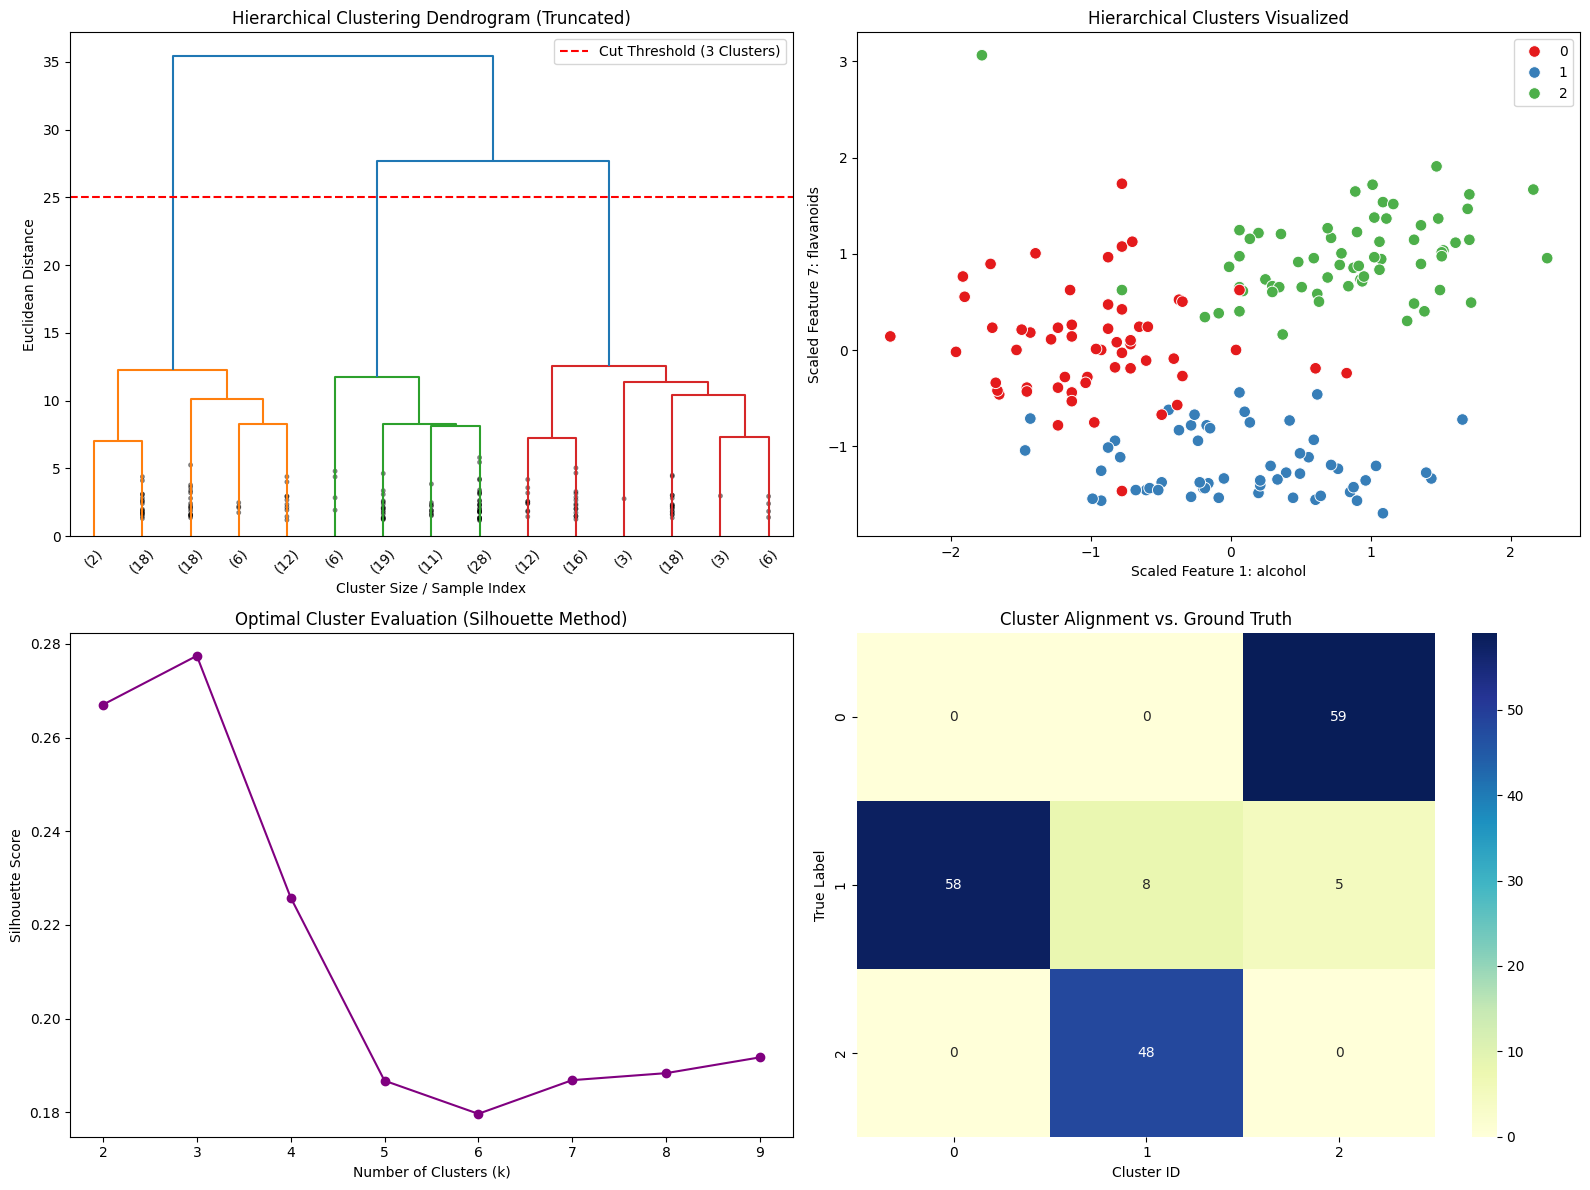

In [ ]:
#visualizations
plt.figure(figsize=(16, 12))  #dendogram
plt.subplot(2, 2, 1)
dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=15,
    leaf_rotation=45,
    leaf_font_size=10,
    show_contracted=True,
)
plt.axhline(
    y=25, color="red", linestyle="--", label="Cut Threshold (3 Clusters)"
)
plt.title("Hierarchical Clustering Dendrogram (Truncated)")
plt.xlabel("Cluster Size / Sample Index")
plt.ylabel("Euclidean Distance")
plt.legend()

plt.subplot(2, 2, 2)   #clusters
sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 6],
    hue=cluster_labels,
    palette="Set1",
    s=70,
)
plt.xlabel(f"Scaled Feature 1: {data.feature_names[0]}")
plt.ylabel(f"Scaled Feature 7: {data.feature_names[6]}")
plt.title("Hierarchical Clusters Visualized")

plt.subplot(2, 2, 3)   #silhouette score across different k values
k_values = range(2, 10)
silhouette_scores = []

for k in k_values:
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = model.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.plot(k_values, silhouette_scores, marker="o", color="purple")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Optimal Cluster Evaluation (Silhouette Method)")

plt.subplot(2, 2, 4)   #cluster assignment vs true class alignment
alignment_df = pd.DataFrame({"True Class": y_true, "Cluster": cluster_labels})
cross_tab = pd.crosstab(
    alignment_df["True Class"],
    alignment_df["Cluster"],
    rownames=["True Label"],
    colnames=["Cluster ID"],
)
sns.heatmap(cross_tab, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Cluster Alignment vs. Ground Truth")

plt.tight_layout()
plt.show()

In [ ]:
#accuracy
print(f"Silhouette Score (Cluster Quality): {sil_score:.4f}")
print(f"Adjusted Rand Index (Alignment with True Classes): {ari_score:.4f}\n")


Silhouette Score (Cluster Quality): 0.2774
Adjusted Rand Index (Alignment with True Classes): 0.7899



In [ ]:
#dynamic tree cutting
from scipy.cluster.hierarchy import fcluster

# Cut the dendrogram tree automatically at a maximum Euclidean distance threshold (e.g., max_d = 25)
max_d = 25
dynamic_labels = fcluster(linkage_matrix, max_d, criterion='distance')

In [ ]:
#dendogrtam and cluster visualizations and plot
plt.figure(figsize=(16, 12))

<Figure size 1600x1200 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

Dynamic Cut Threshold (18.0) identified 3 distinct clusters.


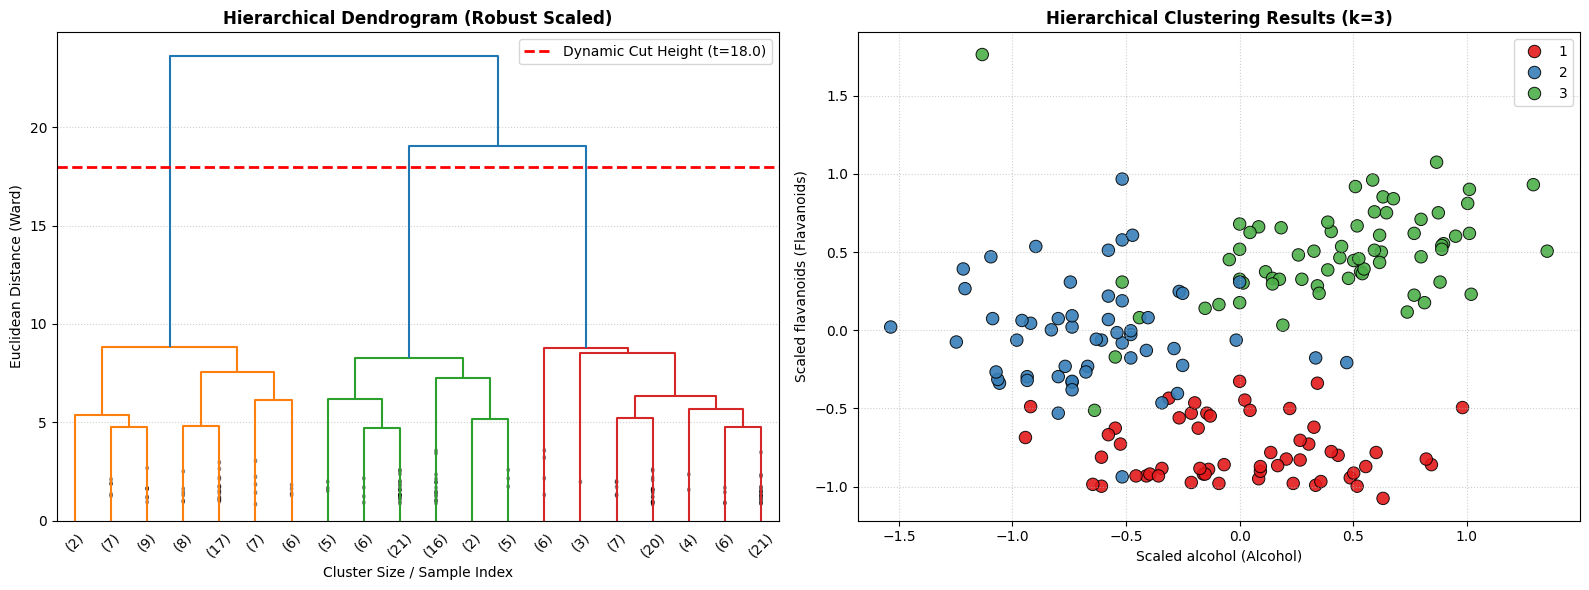

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_wine
from sklearn.preprocessing import RobustScaler

# 1. Load Dataset
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y_true = data.target

# 2. Robust Feature Scaling (Updation #1: Handles outliers better than StandardScaler)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# 3. Generate Linkage Matrix & Perform Dynamic Tree Cutting (Updation #2)
linkage_matrix = linkage(X_scaled, method="ward")

# Dynamic Cut: Set distance threshold dynamically instead of hardcoding k
cut_distance_threshold = 18.0
dynamic_cluster_labels = fcluster(
    linkage_matrix, t=cut_distance_threshold, criterion="distance"
)

# Fit Scikit-Learn Model for validation
n_clusters_found = len(np.unique(dynamic_cluster_labels))
model = AgglomerativeClustering(
    n_clusters=n_clusters_found, metric="euclidean", linkage="ward"
)
sk_labels = model.fit_predict(X_scaled)

print(
    f"Dynamic Cut Threshold ({cut_distance_threshold}) identified {n_clusters_found} distinct clusters."
)

# 4. Visualizations: Dendrogram & Hierarchical Clustering Results
plt.figure(figsize=(16, 6))

# Visualization 1: Detailed Dendrogram with Cut Line
plt.subplot(1, 2, 1)
dendro = dendrogram(
    linkage_matrix,
    truncate_mode="lastp",  # Show top merged nodes
    p=20,
    leaf_rotation=45,
    leaf_font_size=10,
    show_contracted=True,
)
plt.axhline(
    y=cut_distance_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Dynamic Cut Height (t={cut_distance_threshold})",
)
plt.title("Hierarchical Dendrogram (Robust Scaled)", fontsize=12, fontweight="bold")
plt.xlabel("Cluster Size / Sample Index")
plt.ylabel("Euclidean Distance (Ward)")
plt.legend(loc="upper right")
plt.grid(axis="y", linestyle=":", alpha=0.6)

# Visualization 2: Hierarchical Clusters Scatter Plot
plt.subplot(1, 2, 2)
scatter = sns.scatterplot(
    x=X_scaled[:, 0],  # Alcohol
    y=X_scaled[:, 6],  # Flavanoids
    hue=dynamic_cluster_labels,
    palette="Set1",
    s=80,
    edgecolor="k",
    alpha=0.9,
)
plt.title(
    f"Hierarchical Clustering Results (k={n_clusters_found})",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel(f"Scaled {data.feature_names[0]} (Alcohol)")
plt.ylabel(f"Scaled {data.feature_names[6]} (Flavanoids)")
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
#accuracy
from sklearn.metrics import adjusted_rand_score, silhouette_score
print(f"Adjusted Rand Index (Alignment with True Classes): {adjusted_rand_score(y_true, dynamic_cluster_labels):.4f}")
print(f"Silhouette Score (Cluster Quality): {silhouette_score(X_scaled, dynamic_cluster_labels):.4f}")


Adjusted Rand Index (Alignment with True Classes): 0.7436
Silhouette Score (Cluster Quality): 0.2563


In [ ]:
#production pipeline with outer scaling
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
import joblib
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_wine

# Load Data
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)

#Build Pipeline (RobustScaler is less sensitive to extreme outliers)
clustering_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('clusterer', AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward'))
])

#Fit Pipeline and Assign Clusters
cluster_labels = clustering_pipeline.fit_predict(X)
X['assigned_cluster'] = cluster_labels

#Save the Preprocessor & Model State for Inference Pipelines
joblib.dump(clustering_pipeline, "hierarchical_wine_pipeline.pkl")
print("Hierarchical clustering pipeline saved successfully as 'hierarchical_wine_pipeline.pkl'")

Hierarchical clustering pipeline saved successfully as 'hierarchical_wine_pipeline.pkl'


In [ ]:
#predict with new data
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

#Load dataset & create trained pipeline
dataset = load_breast_cancer()
X = dataset.data
y = dataset.target

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42))
])
pipeline.fit(X, y)

#Prepare new unseen sample with matching feature names
new_data = pd.DataFrame([{
    'mean radius': 17.99,
    'mean texture': 10.38,
    'mean perimeter': 122.8,
    'mean area': 1001.0,
    'mean smoothness': 0.1184,
    'mean compactness': 0.2776,
    'mean concavity': 0.3001,
    'mean concave points': 0.1471,
    'mean symmetry': 0.2419,
    'mean fractal dimension': 0.07871,
    'radius error': 1.095,
    'texture error': 0.9053,
    'perimeter error': 8.589,
    'area error': 153.4,
    'smoothness error': 0.006399,
    'compactness error': 0.04904,
    'concavity error': 0.05373,
    'concave points error': 0.01587,
    'symmetry error': 0.03003,
    'fractal dimension error': 0.006193,
    'worst radius': 25.38,
    'worst texture': 17.33,
    'worst perimeter': 184.6,
    'worst area': 2019.0,
    'worst smoothness': 0.1622,
    'worst compactness': 0.6656,
    'worst concavity': 0.7119,
    'worst concave points': 0.2654,
    'worst symmetry': 0.4601,
    'worst fractal dimension': 0.1189
}])

#Predict class & calculate confidence probability
predictions = pipeline.predict(new_data)
probabilities = pipeline.predict_proba(new_data)

predicted_class = dataset.target_names[predictions[0]]
confidence = np.max(probabilities) * 100

print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

Predicted Class: malignant
Confidence: 100.00%


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
